# Evaluation & Threshold Optimization

This is where things get interesting. Instead of just picking the model with the best AUC, we're going to find the **decision threshold that maximizes the bank's profit** given that good loans = +$100 and bad loans = -$500.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, confusion_matrix,
                             classification_report, roc_auc_score)
from src.data_loader import load_raw_data, get_feature_target
from src.preprocessing import split_data, impute_missing, scale_features
from src.feature_engineering import create_interaction_features
from src.evaluation import ks_statistic, optimize_threshold, decile_analysis, gains_chart_data
from src.config import CONFIG

sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
# reload data + models
df = load_raw_data()
X, y = get_feature_target(df)
X_train, X_test, y_train, y_test = split_data(X, y)
X_train, X_test, imputer = impute_missing(X_train, X_test)
X_train_full = create_interaction_features(X_train)
X_test_full = create_interaction_features(X_test)
X_train_sc, X_test_sc, scaler = scale_features(X_train_full, X_test_full)

models = {
    'Logistic Regression': joblib.load('../data/processed/model_logistic_regression.joblib'),
    'Random Forest': joblib.load('../data/processed/model_random_forest.joblib'),
    'XGBoost': joblib.load('../data/processed/model_xgboost.joblib'),
    'LightGBM': joblib.load('../data/processed/model_lightgbm.joblib'),
}

y_probs = {}
for name, model in models.items():
    X_eval = X_test_sc if name == 'Logistic Regression' else X_test_full
    y_probs[name] = model.predict_proba(X_eval)[:, 1]

## ROC curves

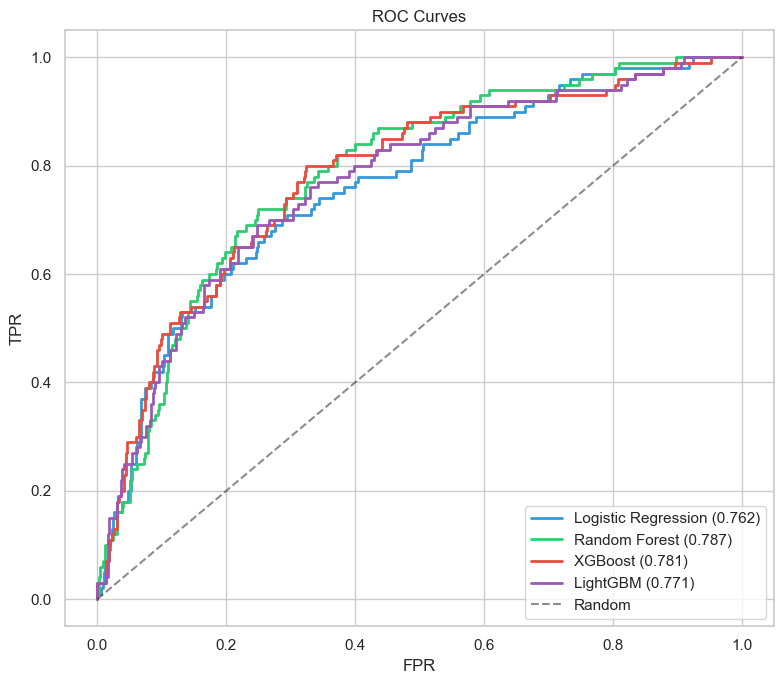

In [3]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for (name, probs), color in zip(y_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} ({auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Precision-Recall curves

More informative than ROC for imbalanced data — PR curves focus on the minority class.

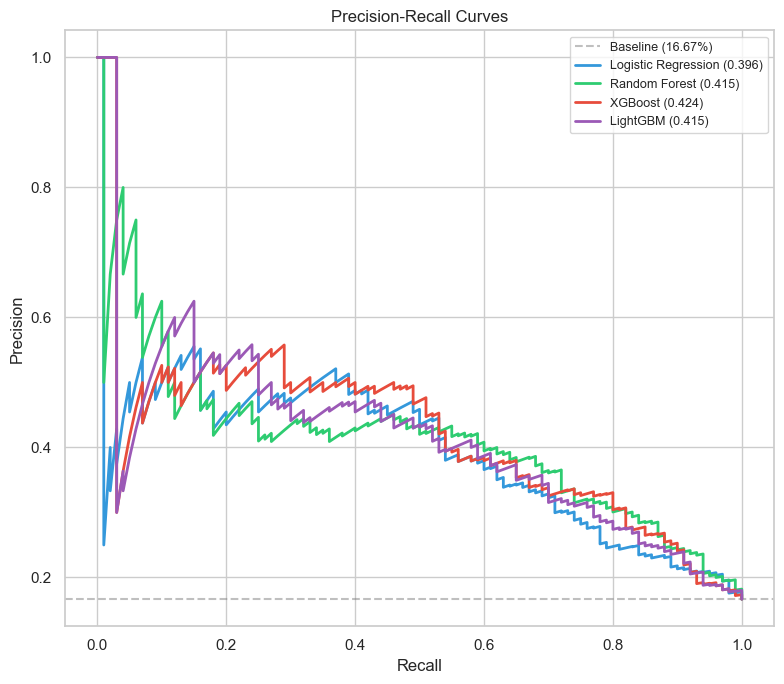

In [4]:
fig, ax = plt.subplots(figsize=(8, 7))
prevalence = y_test.mean()
ax.axhline(y=prevalence, color='gray', linestyle='--', alpha=0.5, label=f'Baseline ({prevalence:.2%})')

for (name, probs), color in zip(y_probs.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    ax.plot(rec, prec, color=color, linewidth=2, label=f'{name} ({pr_auc:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## KS Statistic

This is the metric credit scoring people actually care about. It measures the maximum separation between the good and bad loan distributions. > 0.4 is excellent.

Best model: Random Forest


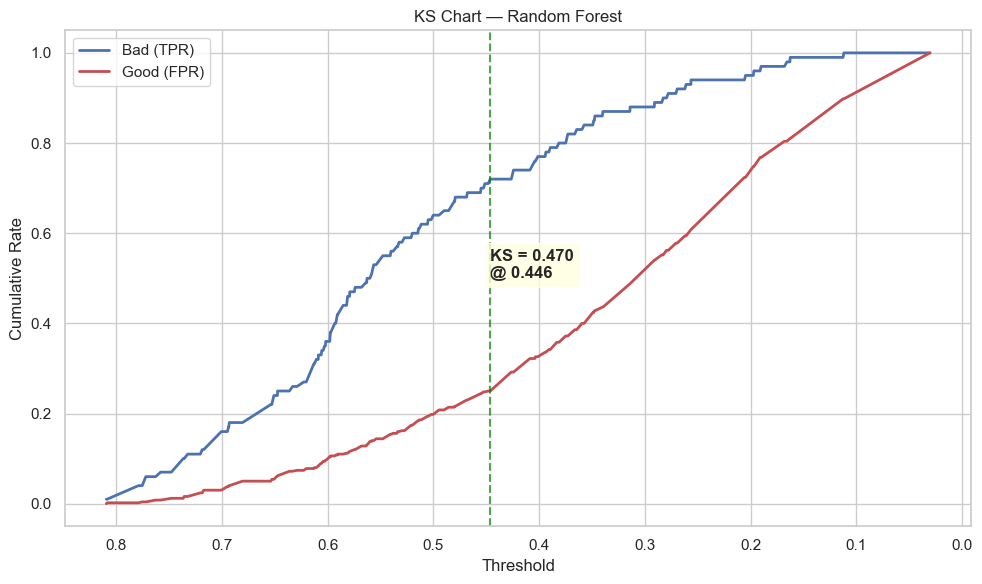

In [5]:
# find best model
best_name = max(y_probs, key=lambda k: roc_auc_score(y_test, y_probs[k]))
best_probs = y_probs[best_name]
print(f"Best model: {best_name}")

ks = ks_statistic(y_test, best_probs)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ks['thresholds'], ks['tpr'][:-1] if len(ks['tpr']) > len(ks['thresholds']) else ks['tpr'],
        'b-', linewidth=2, label='Bad (TPR)')
ax.plot(ks['thresholds'], ks['fpr'][:-1] if len(ks['fpr']) > len(ks['thresholds']) else ks['fpr'],
        'r-', linewidth=2, label='Good (FPR)')
ax.axvline(x=ks['ks_threshold'], color='green', linestyle='--', alpha=0.7)
ax.annotate(f'KS = {ks["ks_statistic"]:.3f}\n@ {ks["ks_threshold"]:.3f}',
            xy=(ks['ks_threshold'], 0.5), fontsize=12, fontweight='bold',
            bbox=dict(facecolor='lightyellow', alpha=0.8))
ax.set_xlabel('Threshold')
ax.set_ylabel('Cumulative Rate')
ax.set_title(f'KS Chart — {best_name}')
ax.legend()
ax.invert_xaxis()
plt.tight_layout()
plt.savefig('../reports/figures/ks_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# KS for all models
print("KS Statistics:")
for name, probs in y_probs.items():
    k = ks_statistic(y_test, probs)
    rating = 'Excellent' if k['ks_statistic'] > 0.4 else 'Good' if k['ks_statistic'] > 0.3 else 'OK'
    print(f"  {name:25s} KS={k['ks_statistic']:.3f} ({rating})")

KS Statistics:
  Logistic Regression       KS=0.416 (Excellent)
  Random Forest             KS=0.470 (Excellent)
  XGBoost                   KS=0.476 (Excellent)
  LightGBM                  KS=0.442 (Excellent)


## Gains & Lift

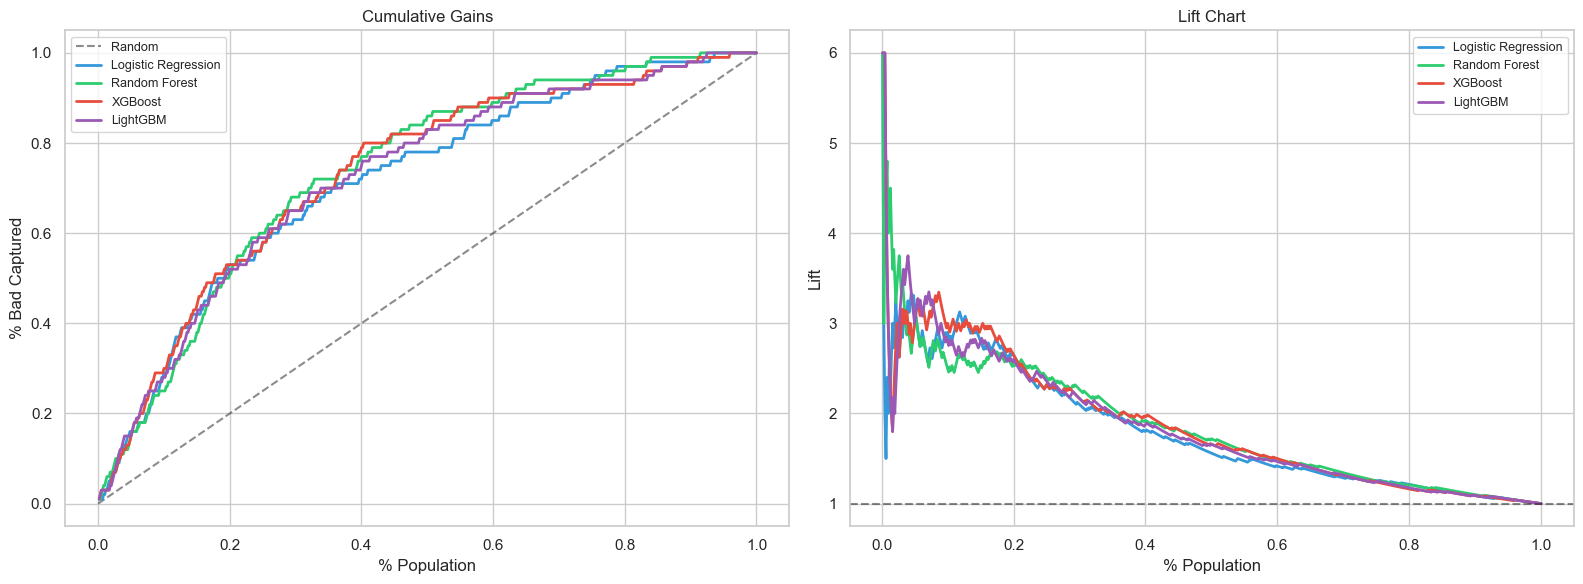

Top 10% captures 25.0% of bad loans
Top 20% captures 51.0% of bad loans
Top 30% captures 68.0% of bad loans
Top 50% captures 86.0% of bad loans


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# gains
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
for (name, probs), color in zip(y_probs.items(), colors):
    pct, capture = gains_chart_data(y_test, probs)
    ax.plot(pct, capture, color=color, linewidth=2, label=name)
ax.set_xlabel('% Population')
ax.set_ylabel('% Bad Captured')
ax.set_title('Cumulative Gains')
ax.legend(fontsize=9)

# lift
ax = axes[1]
for (name, probs), color in zip(y_probs.items(), colors):
    pct, capture = gains_chart_data(y_test, probs)
    lift = np.where(pct > 0, capture / pct, 0)
    ax.plot(pct, lift, color=color, linewidth=2, label=name)
ax.axhline(y=1, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('% Population')
ax.set_ylabel('Lift')
ax.set_title('Lift Chart')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/gains_lift_charts.png', dpi=150, bbox_inches='tight')
plt.show()

# quick summary
pct, capture = gains_chart_data(y_test, best_probs)
for p in [0.10, 0.20, 0.30, 0.50]:
    idx = np.argmin(np.abs(pct - p))
    print(f"Top {p:.0%} captures {capture[idx]:.1%} of bad loans")

## Profit-maximizing threshold

This is the money slide (literally). The default 0.5 threshold is arbitrary. Let's find the one that actually maximizes profit.

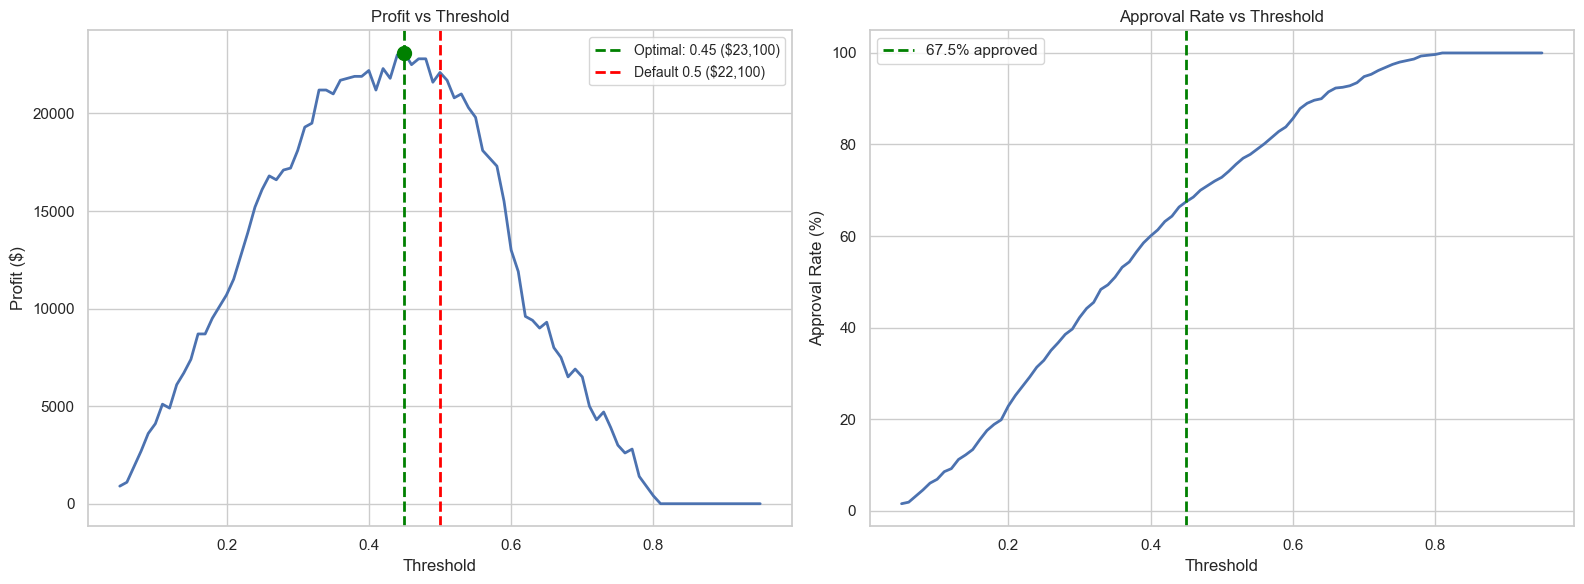


Default (0.5):  $22,100 profit, 72.8% approved
Optimal (0.45): $23,100 profit, 67.5% approved
Improvement: $1,000


In [8]:
profit_df = optimize_threshold(
    y_test.values, best_probs,
    profit_good=CONFIG['profit_good_loan'],
    loss_bad=CONFIG['loss_bad_loan']
)

best_idx = profit_df['profit'].idxmax()
optimal = profit_df.loc[best_idx]

# find the row closest to 0.5 for comparison
default_row = profit_df.iloc[(profit_df['threshold'] - 0.5).abs().argsort().iloc[0]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(profit_df['threshold'], profit_df['profit'], 'b-', linewidth=2)
ax.axvline(x=optimal['threshold'], color='green', linestyle='--', linewidth=2,
           label=f"Optimal: {optimal['threshold']:.2f} (${optimal['profit']:,.0f})")
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2,
           label=f"Default 0.5 (${default_row['profit']:,.0f})")
ax.scatter([optimal['threshold']], [optimal['profit']], color='green', s=100, zorder=5)
ax.set_xlabel('Threshold')
ax.set_ylabel('Profit ($)')
ax.set_title('Profit vs Threshold')
ax.legend(fontsize=10)

ax = axes[1]
ax.plot(profit_df['threshold'], profit_df['approval_rate'] * 100, 'b-', linewidth=2)
ax.axvline(x=optimal['threshold'], color='green', linestyle='--', linewidth=2,
           label=f"{optimal['approval_rate']:.1%} approved")
ax.set_xlabel('Threshold')
ax.set_ylabel('Approval Rate (%)')
ax.set_title('Approval Rate vs Threshold')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/profit_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

improvement = optimal['profit'] - default_row['profit']
print(f"\nDefault (0.5):  ${default_row['profit']:,.0f} profit, {default_row['approval_rate']:.1%} approved")
print(f"Optimal ({optimal['threshold']:.2f}): ${optimal['profit']:,.0f} profit, {optimal['approval_rate']:.1%} approved")
print(f"Improvement: ${improvement:,.0f}")

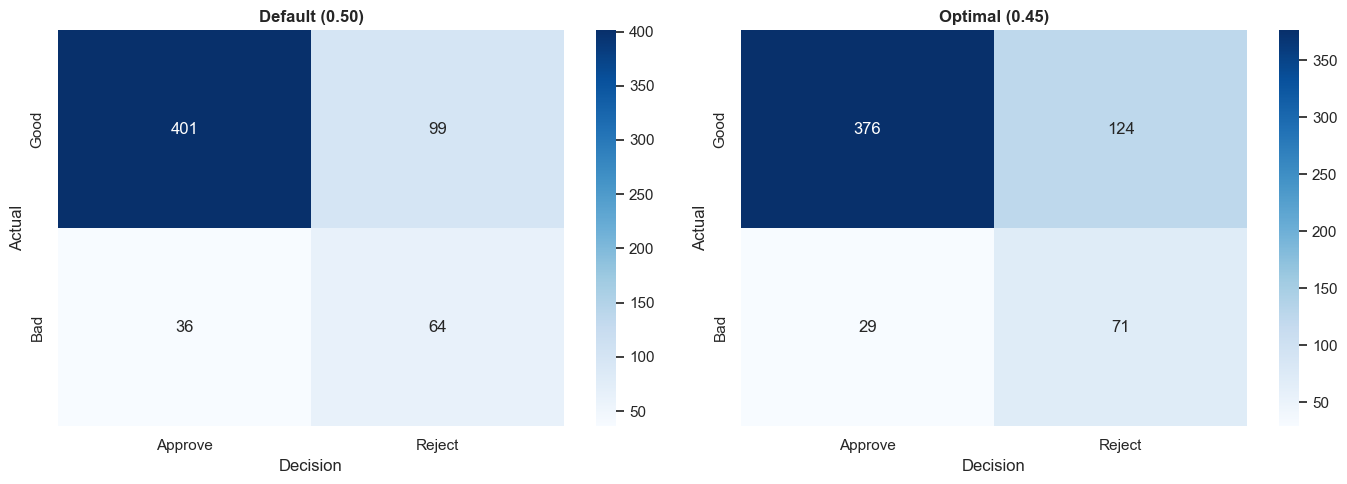

In [9]:
# confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, thresh, title in [
    (axes[0], 0.5, 'Default (0.50)'),
    (axes[1], optimal['threshold'], f'Optimal ({optimal["threshold"]:.2f})')
]:
    y_pred = (best_probs >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Approve', 'Reject'],
                yticklabels=['Good', 'Bad'])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Decision')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Decile analysis

Standard credit scoring report — bad rate should increase monotonically across deciles.

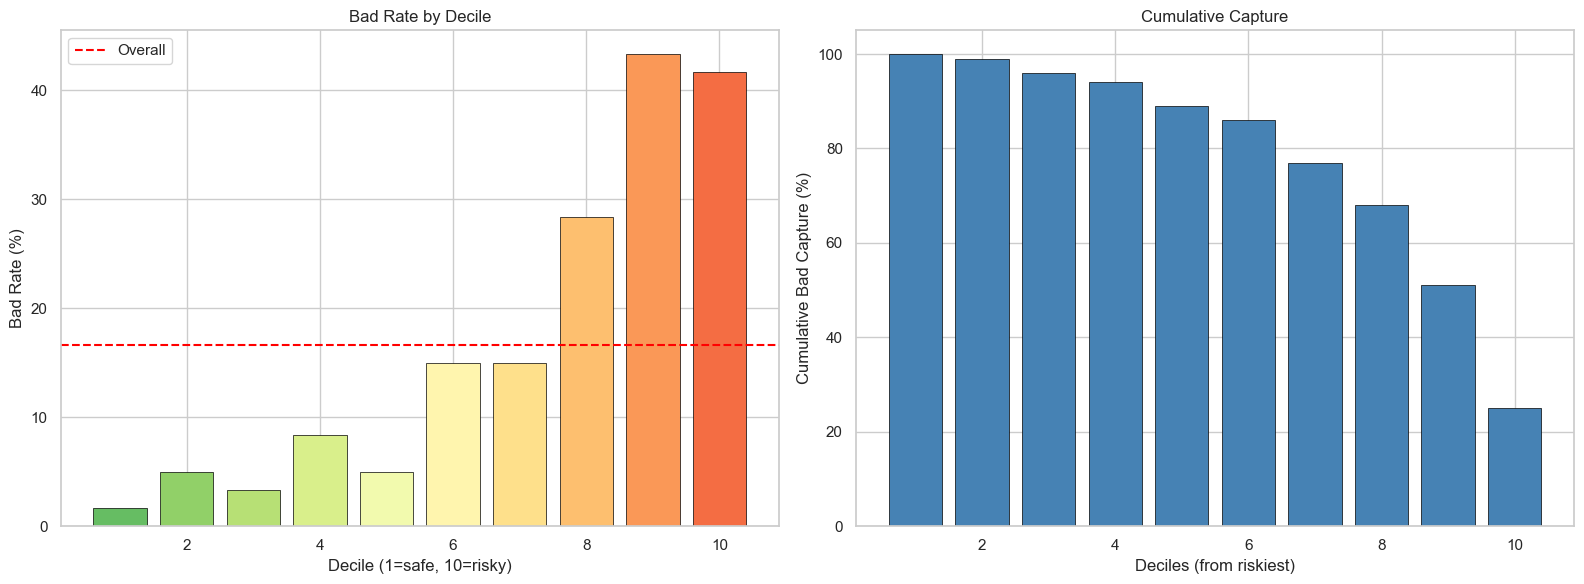

 decile  count  bad_count  bad_rate  cum_bad_capture  avg_prob
      1     60          1     0.017            1.000     0.083
      2     60          3     0.050            0.990     0.156
      3     60          2     0.033            0.960     0.210
      4     60          5     0.083            0.940     0.261
      5     60          3     0.050            0.890     0.315
      6     60          9     0.150            0.860     0.371
      7     60          9     0.150            0.770     0.434
      8     60         17     0.283            0.680     0.516
      9     60         26     0.433            0.510     0.594
     10     60         25     0.417            0.250     0.708

Monotonically increasing: mostly (minor inversions)


In [10]:
dec = decile_analysis(y_test.values, best_probs)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.bar(dec['decile'], dec['bad_rate'] * 100,
       color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(dec))),
       edgecolor='black', linewidth=0.5)
ax.axhline(y=y_test.mean()*100, color='red', linestyle='--', label='Overall')
ax.set_xlabel('Decile (1=safe, 10=risky)')
ax.set_ylabel('Bad Rate (%)')
ax.set_title('Bad Rate by Decile')
ax.legend()

ax = axes[1]
dec_rev = dec.sort_values('decile', ascending=False)
ax.bar(dec_rev['decile'], dec_rev['cum_bad_capture'] * 100,
       color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Deciles (from riskiest)')
ax.set_ylabel('Cumulative Bad Capture (%)')
ax.set_title('Cumulative Capture')

plt.tight_layout()
plt.savefig('../reports/figures/decile_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(dec[['decile', 'count', 'bad_count', 'bad_rate', 'cum_bad_capture', 'avg_prob']].to_string(
    index=False, float_format='%.3f'))

bad_rates = dec.sort_values('decile')['bad_rate'].values
monotonic = all(bad_rates[i] <= bad_rates[i+1] for i in range(len(bad_rates)-1))
print(f"\nMonotonically increasing: {'yes' if monotonic else 'mostly (minor inversions)'}")